# Load Data

In [1]:
from useful import auto199

In [2]:
import imagingPhase.load_data as ld
fn = './phaseAnalysis2/2HTaSe2_bad_78K100.gwy'
import gwyfile
import numpy as np
container = gwyfile.load(fn)
arr = container['/0/data']['data']
arr = arr.reshape([4096,4096])
print('I can read the variables in outside')


imagingPhase package loaded
Directory of data: ./phaseAnalysis
list of files ['2HTaSe2_ah035', '2HTaSe2_aj036', '2HTaSe2_ao_115K037', '2HTaSe2_ap_118K002', '2HTaSe2_bad_78K097', '2HTaSe2_bad_78K100', '2HTaSe2_bae_110K012', '2HTaSe2_bae_110K013']
                                fileName_ntn             Comments_ntn  \
fileName_no_ext                                                         
2HTaSe2_ah035              2HTaSe2_ah035.sxm  1st 110K manual anlysis   
2HTaSe2_aj036              2HTaSe2_aj036.sxm  1st 110K manual anlysis   
2HTaSe2_ao_115K037         2HTaSe2_ao037.sxm  1st 110K manual anlysis   
2HTaSe2_ap_118K002         2HTaSe2_ap002.sxm  1st 110K manual anlysis   
2HTaSe2_bad_78K097    2HTaSe2_bad_78K097.sxm           most clean 160   
2HTaSe2_bad_78K100    2HTaSe2_bad_78K100.sxm                      NaN   
2HTaSe2_bae_110K012  2HTaSe2_bae_110K012.sxm          best 80nm ICCDW   
2HTaSe2_bae_110K012  2HTaSe2_bae_110K012.sxm                      NaN   
2HTaSe2_bae_110K013  2HT

# Quick preprocess

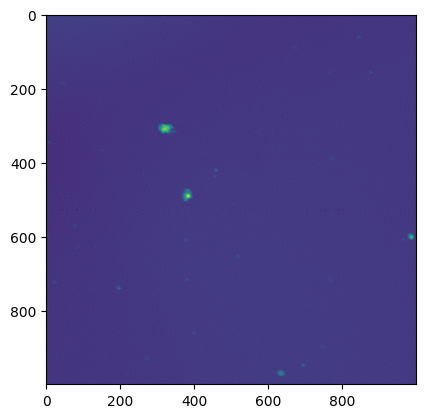

In [3]:
from matplotlib import pyplot as plt
plt.imshow(arr[0:1000,0:1000])

In [4]:
from scipy.ndimage import gaussian_filter
def ceilcut(arr2,threshold=1*10**-10):
  arr2[arr2>threshold] = threshold
  return arr2
def highpass(arr2,sigma=5):
  
  arr2 = arr2 - gaussian_filter(arr2,sigma=sigma)
  return arr2



In [5]:
print(arr.flatten().max())
print(arr.flatten().min())

5.558594945827147e-10
-3.0899292197623216e-10


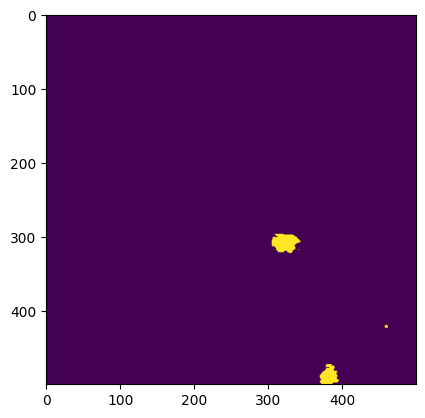

In [6]:
# plt.hist(arr.flatten().max)
plt.imshow(arr[0:500,0:500]>1*10**-10)

d:\github\2H_TaSe2_Tc_STM\2Hvenv\Lib\site-packages\numpy\lib\_function_base_impl.py:4968: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


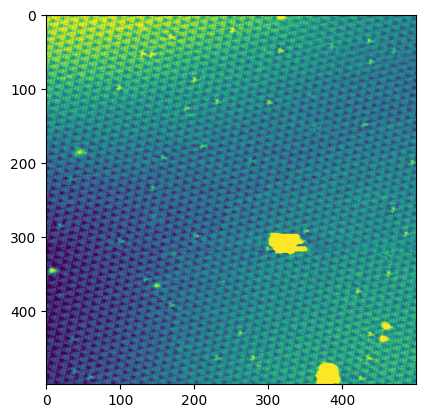

In [7]:
plt.imshow(arr[0:500,0:500])
auto199()

In [8]:
arr_after = highpass(ceilcut(arr)) 

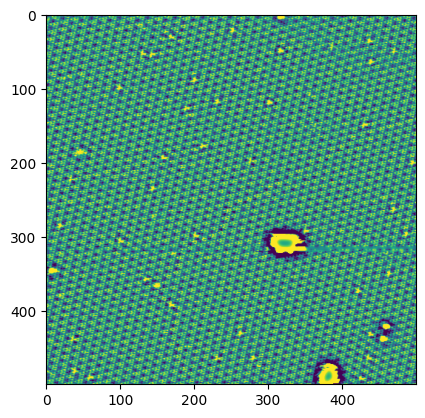

In [9]:
plt.imshow(arr_after[0:500,0:500])
auto199()

In [10]:
# from scipy.fft import fft2, fftshift
# from skimage.feature import peak_local_max
# def fft2show(arr_cln,vmin,vmax):
#   fft_result = fft2(arr_cln)
#   fft_result_shifted = fftshift(fft_result)
#   magnitude_spectrum = np.abs(fft_result_shifted)
#   plt.figure(figsize=(10, 10))
#   plt.imshow(magnitude_spectrum, cmap='gray', vmin=vmin, vmax=vmax)
#   plt.title('Magnitude Spectrum of 2D FFT')
#   return  magnitude_spectrum
# def fft2pkfnd(fft2abs,threshold,choose):
#   coordinates = peak_local_max(fft2abs, min_distance=100, threshold_abs = threshold)
#   plt.scatter(coordinates[:, 1], coordinates[:, 0], s=50, facecolors='none', edgecolors='r')
#   for ipeak in range(coordinates.shape[0]):
#     plt.text(coordinates[ipeak,1],coordinates[ipeak,0],str(ipeak), color='g')
#   coordinates_choose = coordinates[choose,:]
#   print(coordinates_choose)
#   print(coordinates_choose.shape[0])
#   for ipeak in range(coordinates_choose.shape[0]):
#     plt.text(coordinates_choose[ipeak,1],coordinates_choose[ipeak,0],str(ipeak), color='b',size= 20)
#     pk_all = coordinates - (np.array(fft2abs.shape)/2)
#     pk_choose = pk_all[choose,:]
#   return pk_choose,pk_all
arr_cln = arr_after

In [11]:
vmin = 0 # @param
vmax = 0.0000001 # @param
threshold = 0.0000002 # @param
choose = [6,9,12] # @param

In [12]:
from imagingPhase.ffts import fft2show,fft2pkfnd

In [13]:
from imagingPhase.ffts import fft2show,fft2pkfnd

In [14]:
fft2show

<function imagingPhase.ffts.fft2show(arr_cln, vmin=None, vmax=None)>

[[1859 1001]
 [3307 2404]
 [ 963 2744]]
3
[[ -189. -1047.]
 [ 1259.   356.]
 [-1085.   696.]]
[[-4.180e+02 -1.170e+02]
 [ 4.180e+02  1.170e+02]
 [-6.300e+01 -3.470e+02]
 [ 6.300e+01  3.470e+02]
 [-3.600e+02  2.260e+02]
 [ 3.600e+02 -2.260e+02]
 [-1.890e+02 -1.047e+03]
 [ 1.890e+02  1.047e+03]
 [-1.259e+03 -3.560e+02]
 [ 1.259e+03  3.560e+02]
 [-2.070e+02  2.740e+02]
 [ 2.070e+02 -2.740e+02]
 [-1.085e+03  6.960e+02]
 [ 1.085e+03 -6.960e+02]
 [-2.410e+02 -1.000e+00]
 [ 2.410e+02  1.000e+00]
 [-2.950e+02  5.800e+02]
 [ 2.950e+02 -5.800e+02]
 [-4.810e+02 -4.640e+02]
 [ 4.810e+02  4.640e+02]
 [-7.770e+02  1.110e+02]
 [ 7.770e+02 -1.110e+02]
 [-1.217e+03 -7.000e+00]
 [ 1.217e+03  7.000e+00]
 [-1.260e+02 -7.000e+02]
 [ 1.260e+02  7.000e+02]
 [-6.540e+02  8.070e+02]
 [ 6.540e+02 -8.070e+02]
 [-7.220e+02  4.620e+02]
 [ 7.220e+02 -4.620e+02]
 [-8.440e+02 -2.370e+02]
 [ 8.440e+02  2.370e+02]
 [-1.520e+02  1.270e+02]
 [ 1.520e+02 -1.270e+02]
 [-5.460e+02 -8.240e+02]
 [ 5.460e+02  8.240e+02]
 [-2.2

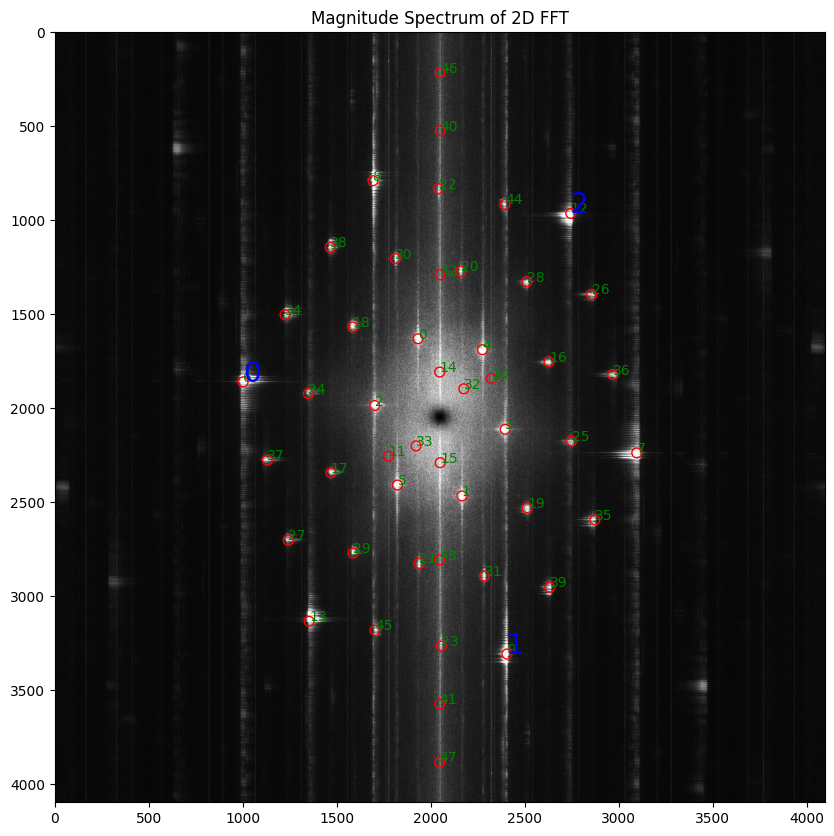

In [15]:
# from imagingPhase import fft2show
fft2abs = fft2show(arr_cln,vmin,vmax)
pk_choose,pk_all = fft2pkfnd(fft2abs,threshold,choose)
print(pk_choose)
print(pk_all)

Text(0.5, 0.98, 'k0')

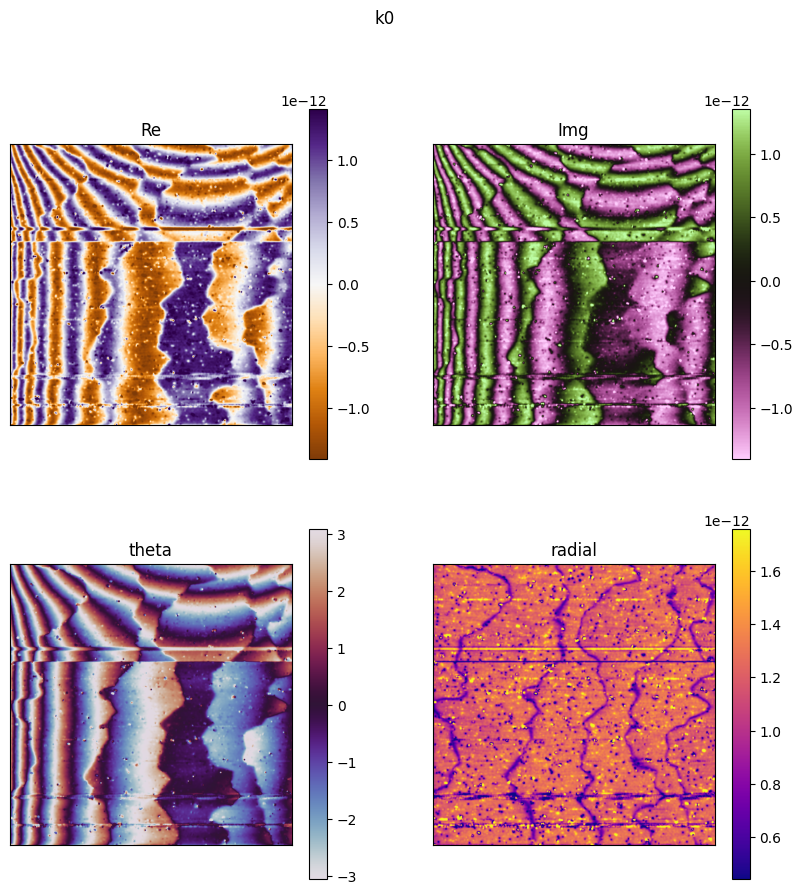

In [16]:
from imagingPhase.get_phimap import kdisplacementmap, visxprod

ik = 0 # @param
k = pk_choose[ik]/3
sig = 10 # @para
xprod = kdisplacementmap(arr_cln,k,sig)
visxprod(xprod)
plt.suptitle("k"+str(ik))


In [17]:
ks_Latt = pk_choose
ks_CDW = pk_choose/3

In [18]:
def wrap_phase(unwrapped_phase):
  """
  Wraps unwrapped phase data into the range of (-pi, pi].

  Args:
    unwrapped_phase: A numpy array containing the unwrapped phase data.

  Returns:
    A numpy array containing the wrapped phase data.
  """
  wrapped_phase = np.mod(unwrapped_phase + np.pi, 2 * np.pi) - np.pi
  return wrapped_phase
from skimage.restoration import unwrap_phase

In [27]:

sig = 20 # @param
angle_restores = []
complexs = []
for ik in range(3):
  k_Latt = ks_Latt[ik]
  k_CDW = ks_CDW[ik]
  complex = kdisplacementmap(arr_cln,k_CDW,sig)
  angle_restore = (unwrap_phase(np.angle(complex))- unwrap_phase(np.angle(kdisplacementmap(arr_cln,k_Latt,sig)))/3)
  angle_restores.append(angle_restore)
  complexs.append(complex)




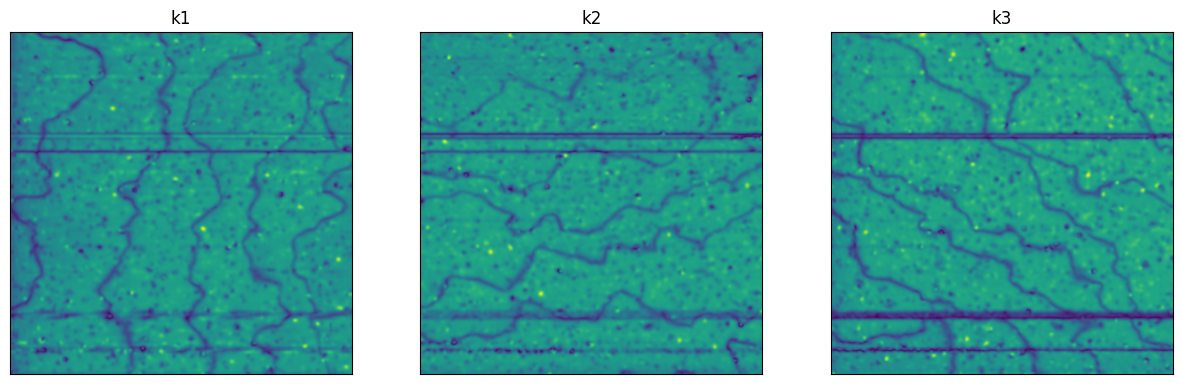

In [20]:
fig,axs = plt.subplots(1,3,figsize=(15, 15))
tns = ['k1','k2','k3']
for ik,tn in zip(range(3),tns):
    # reimg = angle_restores[ik]
    # reimg = wrap_phase(reimg)
    reimg = np.abs(complexs[ik])
    axs[ik].imshow(reimg)
    axs[ik].set_title(tn)
    axs[ik].set_xticks([])
    axs[ik].set_yticks([])

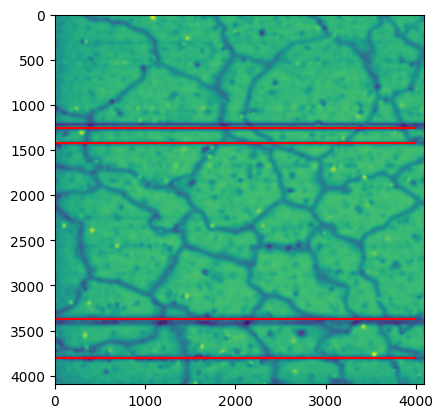

In [21]:
y_surgerys = [1250,1425,3375,3800]
reimg = np.abs(complexs[0])+np.abs(complexs[1])+np.abs(complexs[2])
plt.imshow(reimg)
plt.hlines(y_surgerys,xmin=0,xmax=4000,color='r')

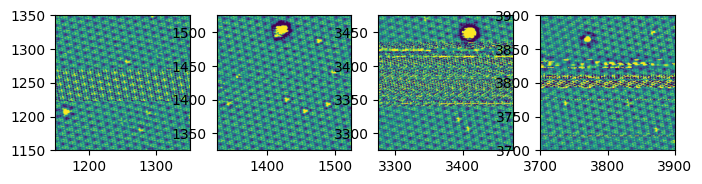

In [22]:
from IPython.core.pylabtools import figsize
l_half = 100
msb,nsb = 1,4
fig,axs = plt.subplots(1,4,figsize=(8,2))
for jsb,ax,y_surgery in zip(range(4),axs,y_surgerys):     
    ax.imshow(arr_cln)
    plt.sca(ax)
    auto199()
    ax.set_xlim([y_surgery-l_half,y_surgery+l_half])
    ax.set_ylim([y_surgery-l_half,y_surgery+l_half])
    
    
        

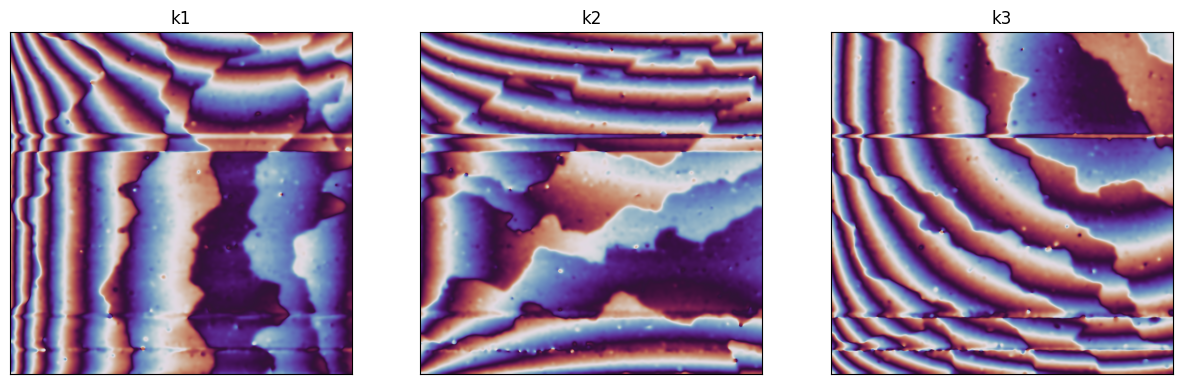

In [28]:
fig,axs = plt.subplots(1,3,figsize=(15, 15))
tns = ['k1','k2','k3']
for ik,tn in zip(range(3),tns):
    # reimg = angle_restores[ik]
    # reimg = wrap_phase(reimg)
    reimg = np.angle(complexs[ik])
    axs[ik].imshow(reimg,cmap='twilight')
    axs[ik].set_title(tn)
    axs[ik].set_xticks([])
    axs[ik].set_yticks([])

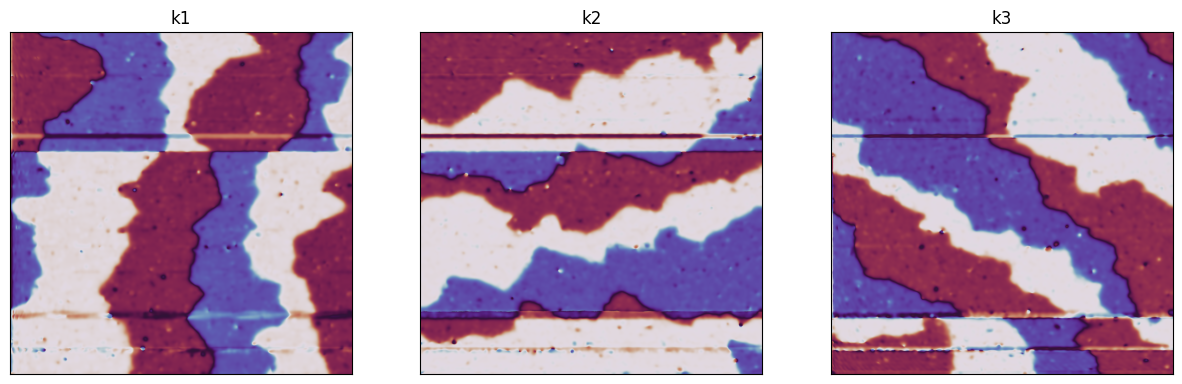

In [29]:
fig,axs = plt.subplots(1,3,figsize=(15, 15))
tns = ['k1','k2','k3']
yns = ['CDW','atom','CDW_compensate']
for ik,tn in zip(range(3),tns):
    reimg = angle_restores[ik]
    reimg = wrap_phase(reimg)
    axs[ik].imshow(reimg, cmap='twilight')
    axs[ik].set_title(tn)
    axs[ik].set_xticks([])
    axs[ik].set_yticks([])

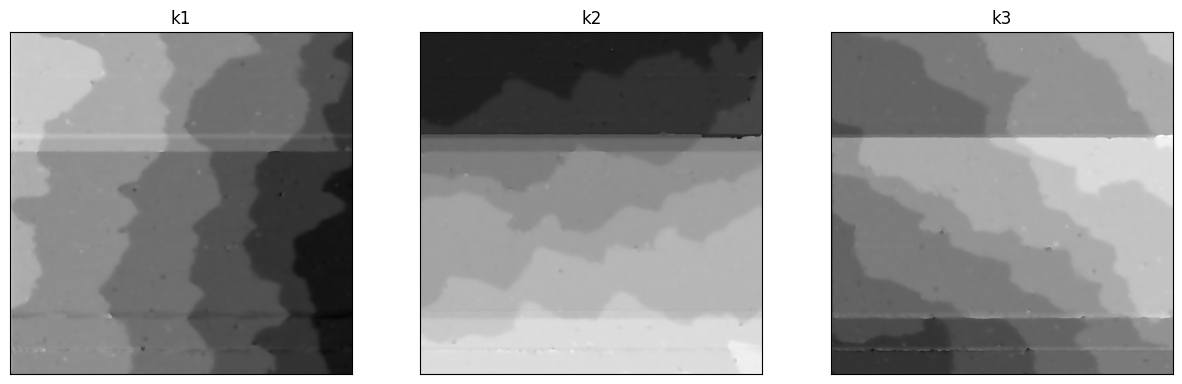

In [31]:
fig,axs = plt.subplots(1,3,figsize=(15, 15))
tns = ['k1','k2','k3']
yns = ['CDW','atom','CDW_compensate']
for ik,tn in zip(range(3),tns):
    reimg = angle_restores[ik]
    # reimg = wrap_phase(reimg)
    axs[ik].imshow(reimg,cmap='gray')
    axs[ik].set_title(tn)
    axs[ik].set_xticks([])
    axs[ik].set_yticks([])

In [71]:
lin = np.arange(4096)
y_surgerys
step1 = (lin>y_surgerys[1])*np.pi*(2/3)- np.pi*(2/3)
step2 = (lin>y_surgerys[0])*np.pi*(2/3)*3 +(lin>y_surgerys[1])*np.pi*(2/3)*2+(lin>y_surgerys[2])*np.pi*(2/3)*2
step3 = (lin>y_surgerys[0])*np.pi*(2/3)*3 +(lin>y_surgerys[2])*np.pi*(2/3)
steps = [step1,step2,step3]

print(foo)

[[0.       ]
 [0.       ]
 [0.       ]
 ...
 [2.0943951]
 [2.0943951]
 [2.0943951]]


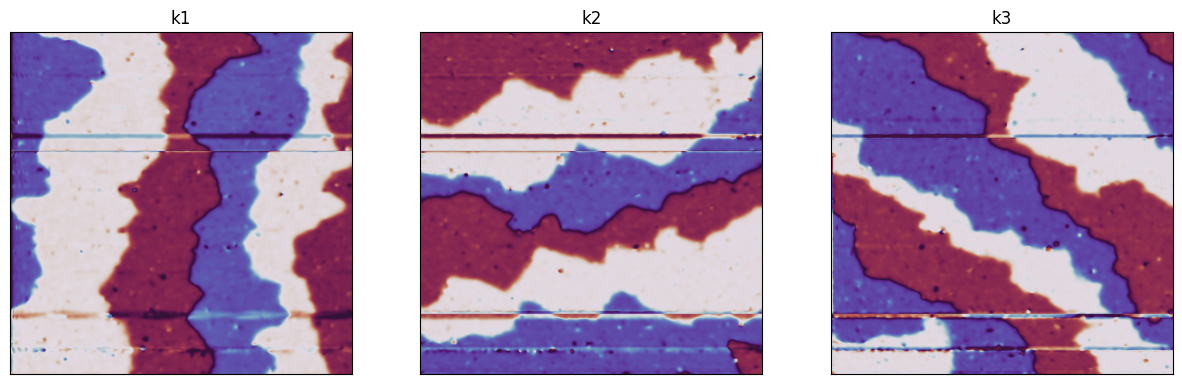

In [72]:
fig,axs = plt.subplots(1,3,figsize=(15, 15))
tns = ['k1','k2','k3']
yns = ['CDW','atom','CDW_compensate']
phase = []
for ik,tn,step in zip(range(3),tns,steps):
    reimg = angle_restores[ik]+step.reshape(4096,1)
    phase.append(reimg)
    reimg = wrap_phase(reimg)
    axs[ik].imshow(reimg, cmap='twilight')
    axs[ik].set_title(tn)
    axs[ik].set_xticks([])
    axs[ik].set_yticks([])

In [83]:
from imagingPhase.visPhase import phiPrinter
pp = phiPrinter([phase[0],-phase[1]])

phase uploaded
phase calculated


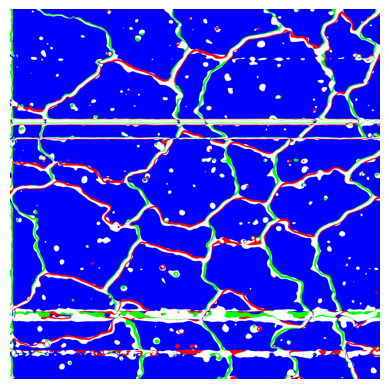

In [84]:
from imagingPhase.visPhase import DWallColoring
dwc = DWallColoring(pp.Info,pp.phase)
dwc.show()